# Trabalho Final: Detecção de Fraude em Transações de Varejo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sbs

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score


## Carregamento e Analise exploratoria do dataset

In [2]:
df = pd.read_csv('retail_fraud_detection_100k.csv')
# ============= Carregamento do dataset


# Ter uma visualização do dataset
df

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,T0099996,C06953,2026-01-01 19:56:25.768931,79.72,Credit Card,Mobile,Australia,Travel,0,1,...,0,990,0,0,0,0,0,0,0,Low
99996,T0099997,C06691,2026-01-25 19:56:25.768949,8.09,PayPal,Desktop,Australia,Luxury,0,2,...,1,1438,1,0,0,0,0,0,0,Low
99997,T0099998,C16351,2025-09-24 19:56:25.768970,94.69,Debit Card,Desktop,Australia,Groceries,1,12,...,3,532,0,0,1,1,0,1,1,Medium
99998,T0099999,C22185,2026-03-06 19:56:25.768990,63.31,Google Pay,Tablet,Australia,Travel,0,9,...,4,556,1,0,0,1,0,0,1,Medium


In [3]:

# Visualização mais geral p ver informacoes como quantidade e nome das colunas,
# seus tipos etc
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100000 non-null  object 
 1   customer_id                       100000 non-null  object 
 2   transaction_timestamp             100000 non-null  object 
 3   transaction_amount                100000 non-null  float64
 4   payment_method                    100000 non-null  object 
 5   device_type                       100000 non-null  object 
 6   location                          100000 non-null  object 
 7   merchant_category                 100000 non-null  object 
 8   is_international                  100000 non-null  int64  
 9   transaction_frequency_24h         100000 non-null  int64  
 10  avg_transaction_amount_7d         100000 non-null  float64
 11  failed_transaction_count_24h      100000 non-null  in

---
### Distribuição

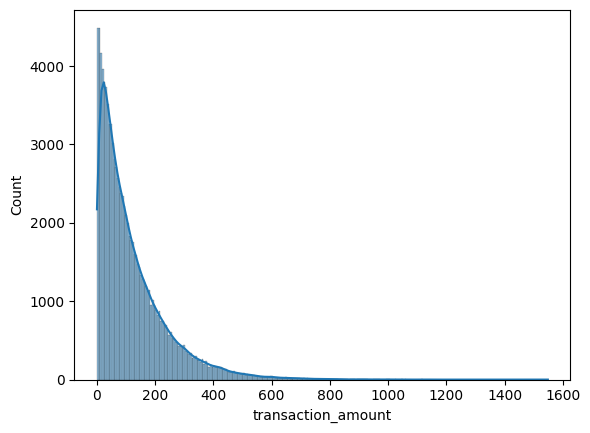

In [4]:
sbs.histplot(df['transaction_amount'], kde=True)
plt.show()

Visualizando esse gráfico podemos identificar que:
* A maioria esmagadora das transações são de valores menores que 200,
* Transações de valores à partir de 600 são extremamente "não-frequentes". Podemos considerá-las `anomalas`.

In [5]:
# fazer um teste pra verificar se esses casos anomalos são casos de fraude:
df['fraud_flag'].value_counts(normalize=True) * 100 # x 100 pra exibir em porcentagem

,proportion
fraud_flag,
0,52.492
1,47.508


Podemos ver que:
* Aproximadamente `52,5%` dos registros sãol legitimos,
* Aproximadamente `47,5%` dos registros são fraudulentos.

Portanto, podemos entender que o dataset está equilibrado e não existe necessidade de reamostragem, uma vez que o numero de ambos casos possiveis(fraudulento ou não) é bem próximo do ideal(50/50) pro caso de "equilibrio perfeito".

---
### Correlação

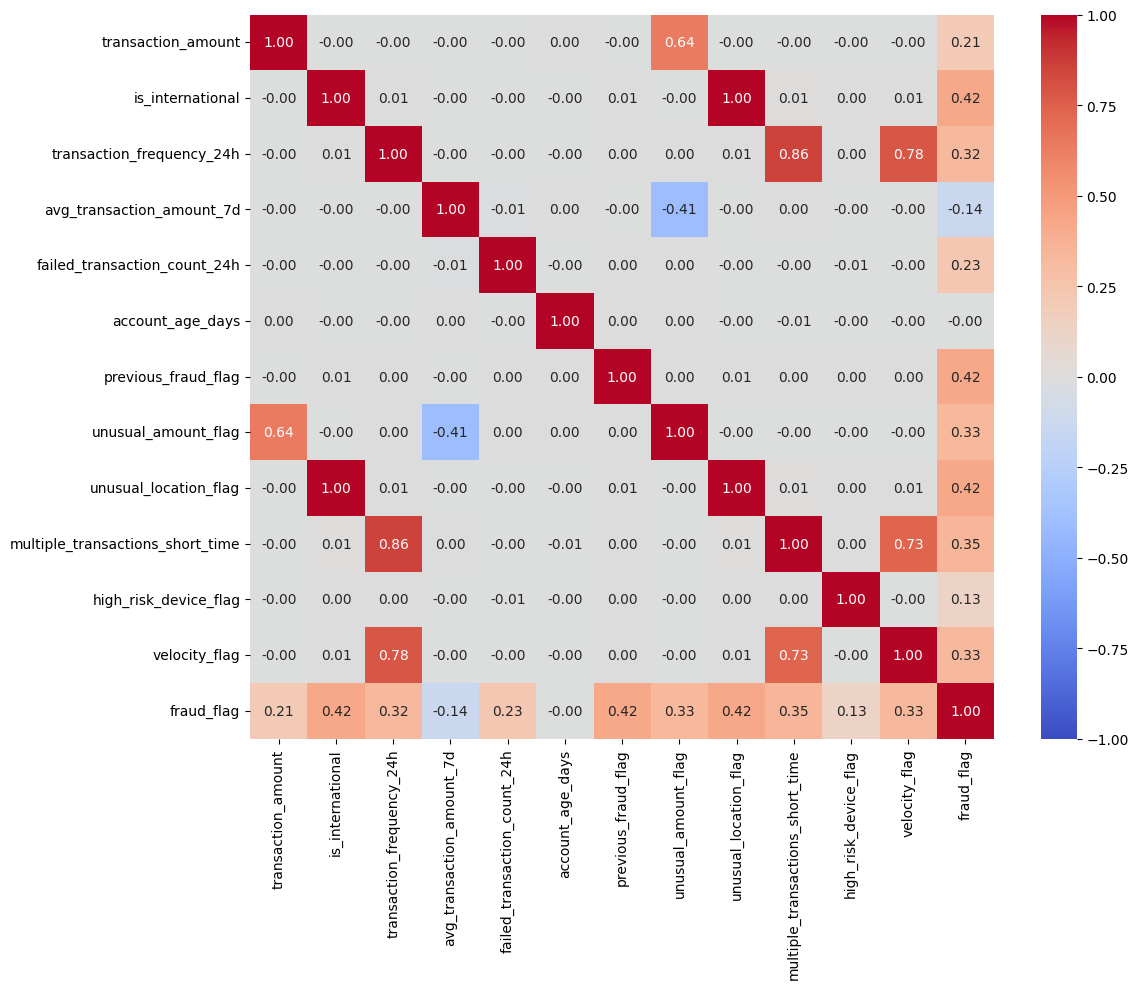

In [6]:
correlacao = df.corr(numeric_only=True)
# Tive que forçar pois o df.corr() sem esse parametro da erro de conversão de
# string pra float.

plt.figure(figsize=(12, 10))

sbs.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.show()

* Analisando o esquema acima, conseguimos detectar:
  * **Colunas Redundantes**: `is_international` e `unusual_location_flag` tem uma correlação perfeita. De acordo com pesquisas, ter colunas redundantes pode atrapalhar o treinamento de alguns modelos. Posteriormente vou tirar uma delas.
  - **Fortes sinais de fraude**: Observando a coluna `fraud_flag` podemos observar algumas colunas com uma correlação consideravel:
    * `is_international`e `unusual_location_flag`(reportadas acima como redundantes) operações feitas no exterior tem correlação de `42%`
    * `previous_fraud_plag`: Operações onde a conta ja tem um histórico de fraude são fortes indicativos também
    * `multiple_transactions_short_time`, `velocity_flag` e `transaction_frequency_24h`: Colunas que indicam varias operacoes em curto espaco de tempo também tem uma correlação razoavel.
---
- Podemos observar uma correlação negativa entre `unusual_amount_flag` e  `avg_transaction_amount_7d` pois quando a média de gastos das operações é muito baixa, qualquer nova operação com valor um pouco maior é vista como valor incomum.


---

## Pré-processamento

In [7]:
# Removendo coluna redundante e colunas desnecessarias pro treinamento
remover_colunas = ['unusual_location_flag','transaction_id', 'customer_id', 'transaction_timestamp', 'unusual_amount_flag']
clean_df = df.drop(columns=remover_colunas)                                                           # Essa 'unusual_amount_flag' eu removi pois os resultados do
                                                                                                      # RandomForest e da Regressão Logística estavam perfeitos.
# Separando variaveis X(explicativas) e Y(alvo)                                                       # Dropando essa coluna, os resultados ficaram mais realistas.
x = clean_df.drop(columns=['fraud_risk', 'fraud_flag'])
y = clean_df['fraud_flag']

# Codificação de variaveis categóricas
x_codificado = pd.get_dummies(x, drop_first=True) # Identifica o que é texto e transforma em 0 e 1.
                                # o drop_first=True Evita redundância, pois em casos onde há apenas duas opções, se não é uma, automaticamente se assume que é a outra.

### Normalização

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x_codificado, y, test_size=0.2, random_state=42)
                                                                      # Definindo que 20% será teste
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print(f"Dados de treino = {x_train.shape}")
print(f"Dados de teste = {x_test.shape}")

# De 100.000, 20%(20k) pra testes e o restante(80% = 80k) pra treino

Dados de treino = (80000, 26)
Dados de teste = (20000, 26)


---

## Treinar e comparar ao menos três modelos de classificação vistos na disciplina

In [9]:
regressao_logistica = LogisticRegression(random_state=42)
knvizinhos = KNeighborsClassifier(n_neighbors=5)
arvore_aleatoria = RandomForestClassifier(random_state=42)

print("Treinando regressão logistica\n\n")
regressao_logistica.fit(x_train, y_train)


Treinando regressão logistica




LogisticRegression(random_state=42)

In [10]:
print("Treinando KNN\n\n")
knvizinhos.fit(x_train, y_train)

Treinando KNN




KNeighborsClassifier()

In [11]:
print("Treinando RandomForest")
arvore_aleatoria.fit(x_train, y_train)

Treinando RandomForest


RandomForestClassifier(random_state=42)

In [12]:
# Gerando previsões
y_previsao_regressao_logistica = regressao_logistica.predict(x_test)
y_probabilidade_regressao_logistica = regressao_logistica.predict_proba(x_test)

y_previsao_knvizinhos = knvizinhos.predict(x_test)
y_probabilidade_knn = knvizinhos.predict_proba(x_test)

y_previsao_arvore_aleatoria = arvore_aleatoria.predict(x_test)
y_probabilidade_arvore_aleatoria = arvore_aleatoria.predict_proba(x_test)

print("Modelos treinados")


Modelos treinados


---

## Avaliar os modelos com métricas apropriadas para dados desbalanceados

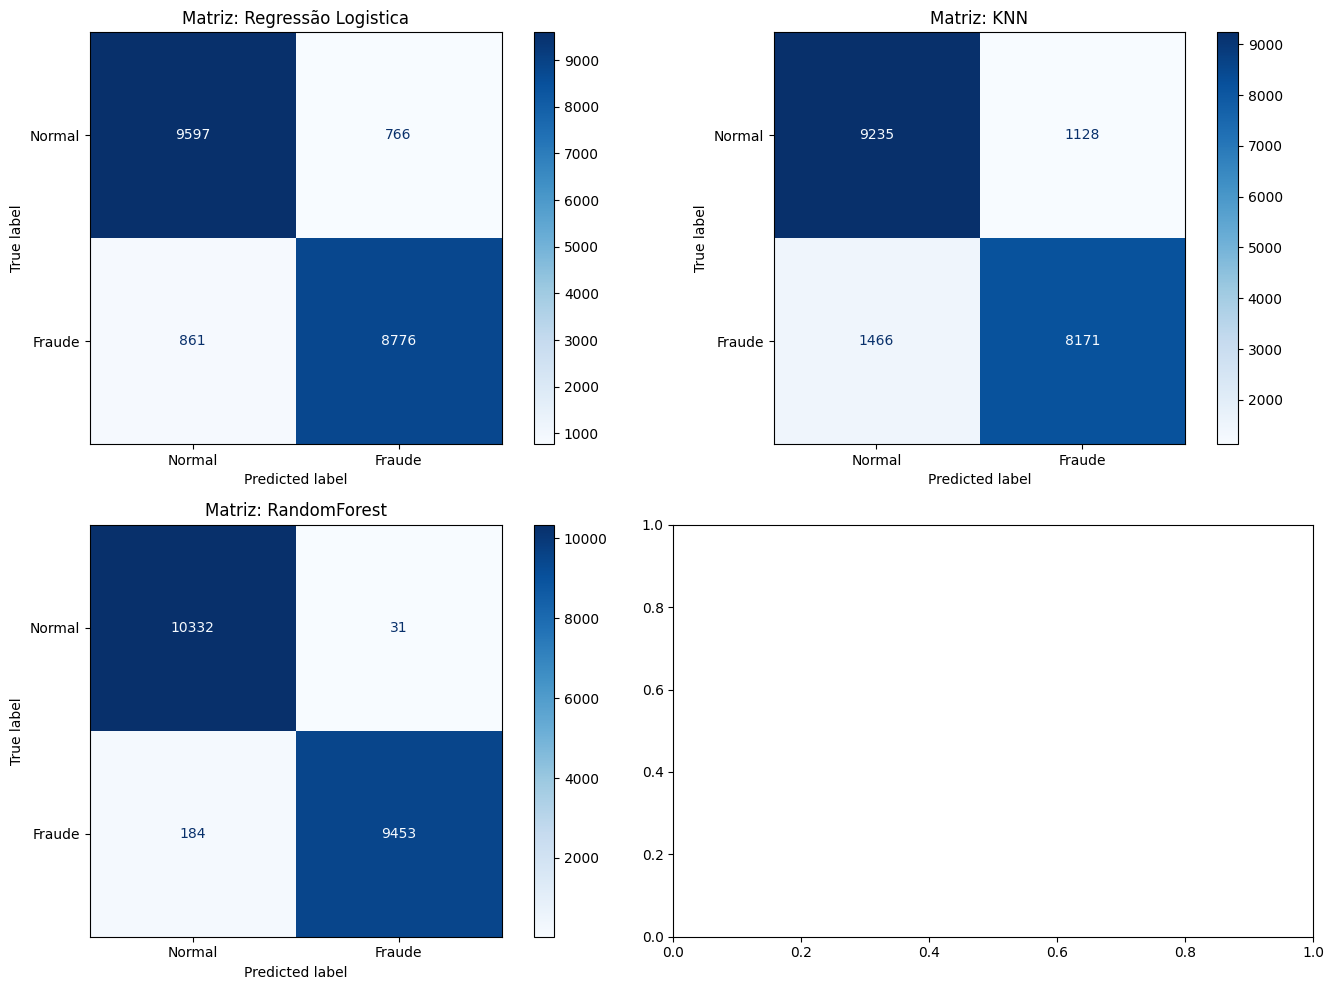

In [13]:
modelos_supervisionados = {
    "Regressão Logistica": [y_previsao_regressao_logistica, y_probabilidade_regressao_logistica],
    "KNN": [y_previsao_knvizinhos, y_probabilidade_knn],
    "RandomForest": [y_previsao_arvore_aleatoria, y_probabilidade_arvore_aleatoria]
}

resultados_metricas = {}

for nome, (y_pred, y_prob) in modelos_supervisionados.items():
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob[:, 1])


    resultados_metricas[nome] = {"F1-Score": f1, "ROC-AUC": auc}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (nome, (y_pred, _)) in enumerate(modelos_supervisionados.items()):
    cm = confusion_matrix(y_test, y_pred),
    disp = ConfusionMatrixDisplay(confusion_matrix=cm[0], display_labels=['Normal', 'Fraude'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Matriz: {nome}')

plt.tight_layout()
plt.show()

In [14]:
# print(resultados_metricas.items())

for resultado in resultados_metricas.items():
    print(f"{resultado[0]}:\n  F1-Score: {resultado[1]['F1-Score']}\n  ROC-AUC: {resultado[1]['ROC-AUC']}\n")

Regressão Logistica:
  F1-Score: 0.915167631263361
  ROC-AUC: 0.9805335192129316

KNN:
  F1-Score: 0.8630122517955218
  ROC-AUC: 0.9399101752388105

RandomForest:
  F1-Score: 0.9887558182103446
  ROC-AUC: 0.9997679342092282



### Comparação dos resultados dos modelos:

* **ROC-AUC**: Todos 3 modelos tiveram resultados excelentes, acima de 90% de confiança(ROC-AUC) na capacidade de distinguir entre as clases(Operações fraudulentas ou verdadeiras).
  * **1º Lugar**: RandomForest obteve a maior porcentagem de confiança(99%)
  * **2º Lugar**: Regressão Logistica: 98%
  * **3º Lugar**: KNN: 93%

* **F1-SCORE**: Média entre precisão(alarmes verdadeiros) e o *Recall*(De todas as fraudes, quantas o modelo detectou corretamente).
  * **1º Lugar**: RandomForest obteve a maior porcentagem(98.87%).
    * Modelo com resultado quase perfeito pra esse caso(Se não tivesse removido a coluna `unusual_amount` teria sido perfeita mesmo).
  * **2º Lugar**: Regressão Logistica: 91%.
    * Resultado inferior ao do RandomForest mas tem um ótimo resultado com um custo computacional muito menor.
  * **3º Lugar**: KNN: 86%
    * Um bom resultado, mas não da pra considerar "Seguro" pra um sistema real.

* **Matriz de Confusão**: A matriz de confusão segue a seguinte estrutura de leitura:

| (Esquerda) | (Direita) |
| :--- | :---: |
| Verdadeiro Negativo | Falso Positivo |
| Falso Negativo | Verdadeiro Positivo |

  * Nessa lógica, temos a seguite leitura/classificação:
    * **1º Lugar**: RandomForest os melhores resultados:
      * 10332 Verdadeiros Negativos( Operações normais foram vistas como normais )
      * 31 Falsos Positivos ( Alarmes Falsos )
      * 184 Operações fraudulentas foram vistas como normais ( Falha de detecção do modelo )
      * 9453 Operações Fraudulentas detectadas com sucesso
    * **2º Lugar**: Regressão Logistica:
      * 9597 Verdadeiros Negativos( Operações normais foram vistas como normais )
      * 766 Falsos Positivos ( Alarmes Falsos )
      * 861 Operações fraudulentas foram vistas como normais ( Falha de detecção do modelo )
      * 8776 Operações Fraudulentas detectadas com sucesso
    * **3º Lugar**: KNN:
      * 9235 Verdadeiros Negativos( Operações normais foram vistas como normais )
      * 1128 Falsos Positivos ( Alarmes Falsos )
      * 1466 Operações fraudulentas foram vistas como normais ( Falha de detecção do modelo )
      * 8171 Operações Fraudulentas detectadas com sucesso

---

## Aplicar ao menos uma técnica de detecção de anomalias (ex: Isolation Forest) e comparar os resultados com os modelos supervisionados

In [15]:
isolation_forest = IsolationForest(contamination=0.48, random_state=42)
                                    # Botei essa taxa de contaminação com base no número de fraud_flags que comentei anteriormente.
isolation_forest.fit(x_train)
y_pred_isolation_forest = isolation_forest.predict(x_test)

y_pred_iforest = np.where(y_pred_isolation_forest == 1, 0, 1)
"""
O Isolation Forest define o valor 1 pra casos normais e -1 pra casos anômalos.

A linha `y_pred_iforest....` é usada para converter esses valores em 0 = Normal e 1 = Fraude
Só fazendo uma conversão pros resultados falarem a mesma lingua
"""

y_prob_iforest = -isolation_forest.decision_function(x_test)
"""
Essa linha faz um processo semelhante ao comentado logo acima, mas agora é quanto a métrica
ROC-AUC. O sinal é invertido pra que valores maiores indiquem maiores probabilidades de ser
um caso fraudulento.
"""



'\nEssa linha faz um processo semelhante ao comentado logo acima, mas agora é quanto a métrica \nROC-AUC. O sinal é invertido pra que valores maiores indiquem maiores probabilidades de ser\num caso fraudulento.\n'

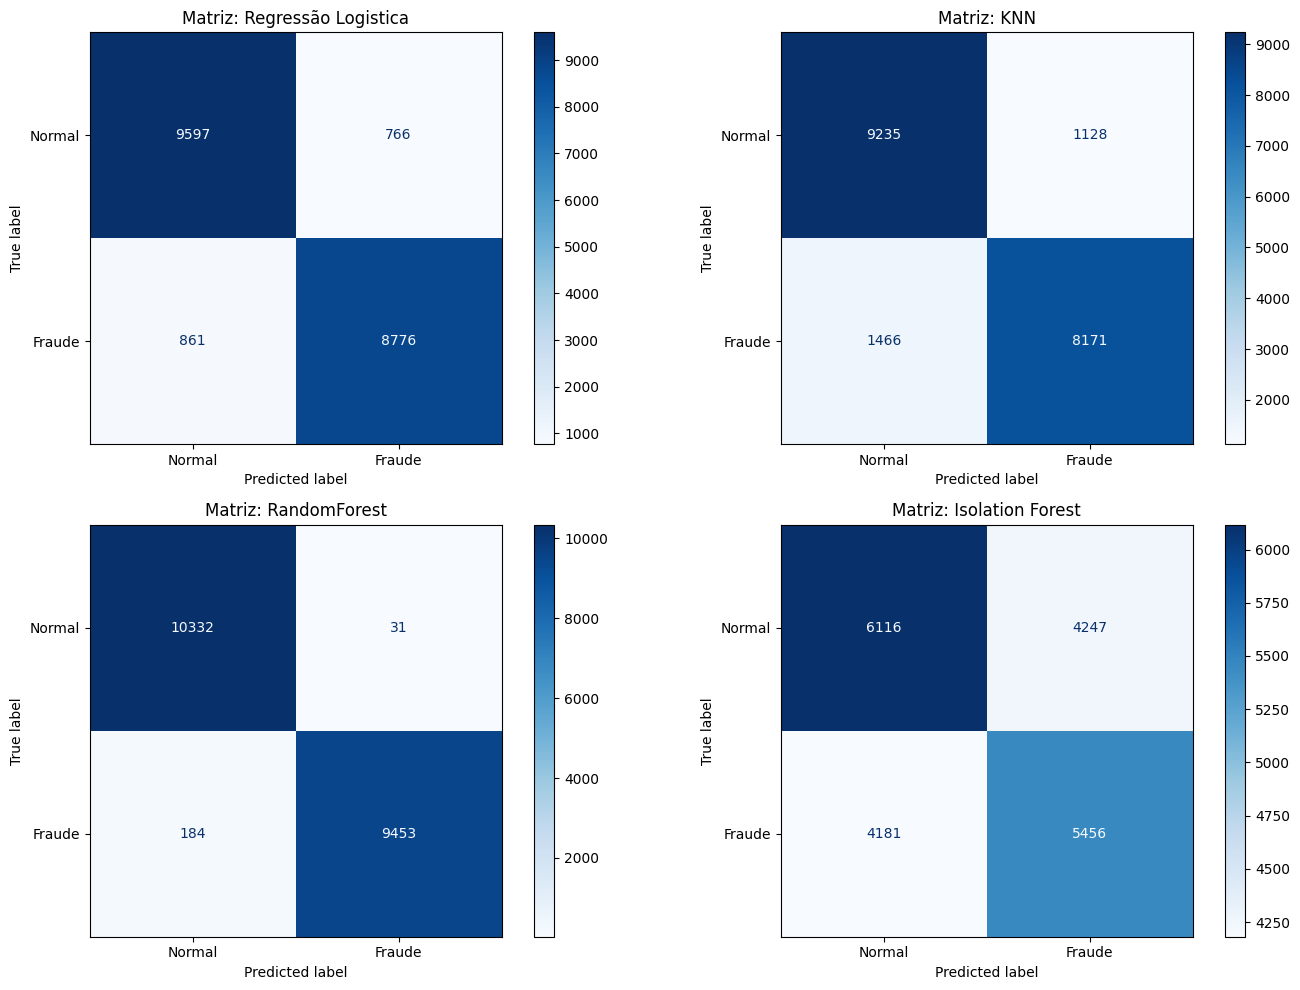

In [17]:
# Repetindo o mesmo código que gerou a Matriz de Confusão anterior:

# Atualizando valores do dict pra incluir o Isolation Forest
modelos_supervisionados = {
    "Regressão Logistica": [y_previsao_regressao_logistica, y_probabilidade_regressao_logistica],
    "KNN": [y_previsao_knvizinhos, y_probabilidade_knn],
    "RandomForest": [y_previsao_arvore_aleatoria, y_probabilidade_arvore_aleatoria],
    "Isolation Forest": [y_pred_iforest, np.column_stack((1 - y_prob_iforest, y_prob_iforest))]
}

resultados_metricas = {}

for nome, (y_pred, y_prob) in modelos_supervisionados.items():
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob[:, 1])


    resultados_metricas[nome] = {"F1-Score": f1, "ROC-AUC": auc}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (nome, (y_pred, _)) in enumerate(modelos_supervisionados.items()):
    cm = confusion_matrix(y_test, y_pred),
    disp = ConfusionMatrixDisplay(confusion_matrix=cm[0], display_labels=['Normal', 'Fraude'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Matriz: {nome}')

plt.tight_layout()
plt.show()

In [ ]:
for resultado in resultados_metricas.items():
    print(f"{resultado[0]}:\n  F1-Score: {resultado[1]['F1-Score']}\n  ROC-AUC: {resultado[1]['ROC-AUC']}\n")

### Comparação com os Modelos Supervisionados:

* O Isolation Forest teve o pior desempenho entre os modelos, o que faz total sentido quando entendemos que esse modelo não tem uma base do que é uma anomalia. Ele simplesmente tenta detectar "o que é diferente" num contexto.
  * Como ja dito anteriormente, o dataset está com uma divisão quase perfeita de numero de operações fraudulentas e operações normais. O resultado reflete a dificuldade de encontrar/definir o que é "diferente" num contexto onde ambos os casos tem "frequencias/ocorrências" quase iguais.
  ---

## Discutir os resultados e indicar o modelo mais adequado para o problema

* Analisando os resultados a seguir, conseguimos dizer com segurança que, dos modelos testados aqui, o `RandomForest`é o mais adequado para o caso. O único possivel concorrente analisado aqui seria o modelo de `Regressão Logística`, que apresentou resultados excelentes(porem inferiores aos do RandomForest) e apresenta um custo computacional menor do que o RandomForest.
---
### Resultados:
---
* **ROC-AUC**: Capacidade de distinguir entre as clases(Operações fraudulentas ou verdadeiras).
  * **1º Lugar**: RandomForest obteve a maior porcentagem de confiança(99%)
  * **2º Lugar**: Regressão Logistica: 98%
  * **3º Lugar**: KNN: 93%
  * **4º Lugar**: Isolation Forest: 61,8%

* **F1-SCORE**: Média entre precisão(alarmes verdadeiros) e o *Recall*(De todas as fraudes, quantas o modelo detectou corretamente).
  * **1º Lugar**: RandomForest obteve a maior porcentagem(98.87%).
    * Modelo com resultado quase perfeito pra esse caso(Se não tivesse removido a coluna `unusual_amount` teria sido perfeita mesmo).
  * **2º Lugar**: Regressão Logistica: 91%.
    * Resultado inferior ao do RandomForest mas tem um ótimo resultado com um custo computacional muito menor.
  * **3º Lugar**: KNN: 86%
    * Um bom resultado, mas não da pra considerar "Seguro" pra um sistema real.
  * **4º Lugar**: Isolation Forest: 56,4%.


* **Matriz de Confusão**: A matriz de confusão segue a seguinte estrutura de leitura:

| (Esquerda) | (Direita) |
| :--- | :---: |
| Verdadeiro Negativo | Falso Positivo |
| Falso Negativo | Verdadeiro Positivo |

  * Nessa lógica, temos a seguite leitura/classificação:
    * **1º Lugar**: RandomForest os melhores resultados:
      * 10332 Verdadeiros Negativos( Operações normais foram vistas como normais )
      * 31 Falsos Positivos ( Alarmes Falsos )
      * 184 Operações fraudulentas foram vistas como normais ( Falha de detecção do modelo )
      * 9453 Operações Fraudulentas detectadas com sucesso
    * **2º Lugar**: Regressão Logistica:
      * 9597 Verdadeiros Negativos( Operações normais foram vistas como normais )
      * 766 Falsos Positivos ( Alarmes Falsos )
      * 861 Operações fraudulentas foram vistas como normais ( Falha de detecção do modelo )
      * 8776 Operações Fraudulentas detectadas com sucesso
    * **3º Lugar**: KNN:
      * 9235 Verdadeiros Negativos( Operações normais foram vistas como normais )
      * 1128 Falsos Positivos ( Alarmes Falsos )
      * 1466 Operações fraudulentas foram vistas como normais ( Falha de detecção do modelo )
      * 8171 Operações Fraudulentas detectadas com sucesso
    * **4º Lugar**: Isolation Forest:
      * 6116 Verdadeiros Negativos( Operações normais foram vistas como normais )
      * 4247 Falsos Positivos ( Alarmes Falsos )
      * 4181 Operações fraudulentas foram vistas como normais ( Falha de detecção do modelo )
      * 5456 Operações Fraudulentas detectadas com sucesso
